<a href="https://colab.research.google.com/github/abdoyanes/Point-Cloud-Data_analysis/blob/main/WhiteNile_ERA5_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ERA5 Physical Mechanism Figures — White Nile Corridor
## Addressing editor's request for circulation-level evidence

---

### ⚠️ BEFORE YOU START — One-time setup (5 minutes)

You need a **free CDS account** to download ERA5 data.

1. Go to: **https://cds.climate.copernicus.eu**
2. Click **Register** (top right) → fill in name, email, password → verify email
3. Log in → click your **username** (top right) → **My Profile**
4. Scroll down to **API key** section → copy your **UID** (a number) and **API key** (a long string)
5. Come back here and paste them in **Cell 2** below

---

### What this notebook produces
| Figure | Purpose |
|---|---|
| **Fig A1** | 850 hPa wind + moisture flux: Pre-1995 vs Post-1995 |
| **Fig A2** | AMO index + station temperature overlay |
| **Fig A3** | TEJ (200 hPa) + AEJ (600 hPa) ENSO composites |
| **Fig A4** | VIMFD moisture convergence ENSO composites |

**Run cells in order, top to bottom. Do not skip any cell.**

---
## CELL 1 — Install packages
**Run this first. It takes 2–3 minutes. You will see a lot of text — that is normal.**

You only need to run this once per Colab session.

In [3]:
# CELL 1 — Install all required packages
# Run this and wait for it to finish before moving to Cell 2

!pip install -q cdsapi xarray netCDF4 scipy matplotlib numpy pandas requests

# Try to install cartopy (for map backgrounds — optional but recommended)
try:
    !pip install -q cartopy
    import cartopy
    print('✅ Cartopy installed — figures will have map backgrounds')
except:
    print('⚠️  Cartopy not available — figures will use plain lat/lon axes (still publishable)')

print('\n✅ All packages installed. Move to Cell 2.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 58.7 MB/s eta 0:00:00
✅ Cartopy installed — figures will have map backgrounds

✅ All packages installed. Move to Cell 2.


---
## CELL 2 — Enter your CDS API credentials

**Replace the two values below with your own UID and API key from your CDS profile.**

Your UID is a number like `123456`  
Your API key looks like `xxxxxxxx-xxxx-xxxx-xxxx-xxxxxxxxxxxx`

Do not share these with anyone.

In [4]:
# CELL 2 — NEW VERSION (paste your Personal Access Token only)
# ============================================================
CDS_TOKEN = 'c39d7ae1-65f9-4305-b598-26051cdd2c83'   # from cds.climate.copernicus.eu/profile
# ============================================================

import os

with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
    f.write(f'url: https://cds.climate.copernicus.eu/api\n')
    f.write(f'key: {CDS_TOKEN}\n')
    f.write('verify: 1\n')

# Test connection
try:
    import cdsapi
    c = cdsapi.Client(quiet=True)
    print('✅ CDS API connected. Move to Cell 3.')
except Exception as e:
    print(f'❌ Failed: {e}')
    print('   Check your token at cds.climate.copernicus.eu/profile')

✅ CDS API connected. Move to Cell 3.


---
## CELL 3 — Upload your station temperature files

Upload these two files from your computer:
- `Temp_Kosti.xlsx`
- `Temp_Ed_Dueim.xlsx`

Run the cell — a file picker will appear. Select both files.

In [10]:
from google.colab import files
uploaded = files.upload()


Saving Temp_Dom.xlsx to Temp_Dom.xlsx
Saving Temp_Kosti.xlsx to Temp_Kosti.xlsx


In [13]:
import io
import pandas as pd

tp_ko_df = pd.read_excel(io.BytesIO(uploaded['Temp_Kosti.xlsx']))
tp_ed_df = pd.read_excel(io.BytesIO(uploaded['Temp_Dom.xlsx']))

# Compute annual means
ann_ko = tp_ko_df.groupby('Year')['Mean'].mean()
ann_ed = tp_ed_df.groupby('Year')['Mean'].mean()
yrs_temp = ann_ko.index.values.astype(int)

print(f'\n✅ Temperature data loaded:')
print(f'   Kosti:    {yrs_temp[0]}–{yrs_temp[-1]}, mean = {ann_ko.mean():.2f} °C')
print(f'   Ed Dueim: {yrs_temp[0]}–{yrs_temp[-1]}, mean = {ann_ed.mean():.2f} °C')
print('\nMove to Cell 4.')


✅ Temperature data loaded:
   Kosti:    1952–2022, mean = 29.22 °C
   Ed Dueim: 1952–2022, mean = 28.70 °C

Move to Cell 4.


---
## CELL 4 — Download ERA5 pressure-level data

This downloads ERA5 monthly wind and humidity fields at 850, 600, and 200 hPa for June–September 1952–2022.

**⚠️ This takes 10–20 minutes and downloads ~400 MB. Do not close the browser.**

The file is saved to Colab's temporary storage. It will be reused if you re-run this cell.

In [14]:
# CELL 4 — Download ERA5 pressure-level data (wind + humidity)
import cdsapi, os

PL_FILE = 'era5_pressure_levels_JJAS.nc'
LON0, LON1 = 18.0, 50.0   # Sudan + surrounding region
LAT0, LAT1 =  4.0, 26.0

if os.path.exists(PL_FILE):
    print(f'✅ File already downloaded: {PL_FILE}')
    print(f'   Size: {os.path.getsize(PL_FILE)/1e6:.1f} MB')
else:
    print('Downloading ERA5 pressure-level data...')
    print('This takes 10–20 minutes. Progress appears below.')
    c = cdsapi.Client()
    c.retrieve(
        'reanalysis-era5-pressure-levels-monthly-means',
        {
            'product_type'  : 'monthly_averaged_reanalysis',
            'variable'      : [
                'u_component_of_wind',
                'v_component_of_wind',
                'specific_humidity',
            ],
            'pressure_level': ['200', '600', '850'],
            'year'          : [str(y) for y in range(1952, 2023)],
            'month'         : ['06', '07', '08', '09'],
            'time'          : '00:00',
            'area'          : [LAT1+5, LON0-5, LAT0-5, LON1+5],
            'format'        : 'netcdf',
        },
        PL_FILE
    )
    print(f'\n✅ Downloaded: {PL_FILE} ({os.path.getsize(PL_FILE)/1e6:.1f} MB)')

print('\nMove to Cell 5.')

This takes 10–20 minutes. Progress appears below.


2026-07-26 17:22:05,914 INFO Request ID is 36afde78-bde5-4081-88ee-6acf977f6147
INFO:ecmwf.datastores.legacy_client:Request ID is 36afde78-bde5-4081-88ee-6acf977f6147
2026-07-26 17:22:06,052 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-26 17:22:29,011 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


31ec08700217d4690b9ad45cf2b69029.nc:   0%|          | 0.00/101M [00:00<?, ?B/s]


✅ Downloaded: era5_pressure_levels_JJAS.nc (106.2 MB)

Move to Cell 5.


---
## CELL 5 — Download ERA5 moisture flux divergence data

This downloads the Vertically Integrated Moisture Flux Divergence (VIMFD) — the variable that directly shows where moisture is converging (rainfall-generating) or diverging.

**⚠️ Takes 3–5 minutes, ~80 MB.**

In [15]:
# CELL 5 — Download ERA5 VIMFD (moisture flux divergence)
import cdsapi, os

SL_FILE = 'era5_vimfd_JJAS.nc'

if os.path.exists(SL_FILE):
    print(f'✅ File already downloaded: {SL_FILE}')
    print(f'   Size: {os.path.getsize(SL_FILE)/1e6:.1f} MB')
else:
    print('Downloading ERA5 VIMFD data...')
    c = cdsapi.Client()
    c.retrieve(
        'reanalysis-era5-single-levels-monthly-means',
        {
            'product_type'  : 'monthly_averaged_reanalysis',
            'variable'      : [
                'vertical_integral_of_divergence_of_moisture_flux',
            ],
            'year'          : [str(y) for y in range(1952, 2023)],
            'month'         : ['06', '07', '08', '09'],
            'time'          : '00:00',
            'area'          : [LAT1+5, LON0-5, LAT0-5, LON1+5],
            'format'        : 'netcdf',
        },
        SL_FILE
    )
    print(f'\n✅ Downloaded: {SL_FILE} ({os.path.getsize(SL_FILE)/1e6:.1f} MB)')

print('\nMove to Cell 6.')

2026-07-26 17:22:50,351 INFO Request ID is c3a2f883-3645-4f32-a57c-f3063f81aea6
INFO:ecmwf.datastores.legacy_client:Request ID is c3a2f883-3645-4f32-a57c-f3063f81aea6
2026-07-26 17:22:50,478 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-26 17:23:04,396 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-26 17:23:12,150 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


6e8759ee77a85e0ba455d004b4f605d4.nc:   0%|          | 0.00/15.7M [00:00<?, ?B/s]


✅ Downloaded: era5_vimfd_JJAS.nc (16.4 MB)

Move to Cell 6.


---
## CELL 6 — Download AMO index from NOAA (free, instant)

The Atlantic Multidecadal Oscillation (AMO) index from NOAA is used to show the physical basis of the 1995 regime shift. No login needed.

In [16]:
# CELL 6 — Download AMO index from NOAA PSL
import requests, pandas as pd, numpy as np

url = 'https://psl.noaa.gov/data/correlation/amon.us.long.data'
JJAS = [6, 7, 8, 9]

try:
    resp = requests.get(url, timeout=30)
    lines = resp.text.strip().split('\n')
    rows = []
    for line in lines[1:]:       # skip header
        vals = line.split()
        if len(vals) < 13: continue
        yr = int(float(vals[0]))
        for m, v in enumerate(vals[1:13], start=1):
            try:
                fv = float(v)
                if abs(fv) < 99:
                    rows.append({'year':yr,'month':m,'amo':fv})
            except: pass
    df = pd.DataFrame(rows)
    amo_df = (df[df['month'].isin(JJAS)]
                .groupby('year')['amo'].mean()
                .reset_index()
                .query('year >= 1952 and year <= 2022'))
    print(f'✅ AMO index loaded: {len(amo_df)} annual JJAS values (1952–2022)')
    print(f'   Pre-1995 mean:  {amo_df[amo_df.year < 1995].amo.mean():+.3f} °C (cold phase)')
    print(f'   Post-1995 mean: {amo_df[amo_df.year >= 1995].amo.mean():+.3f} °C (warm phase)')
except Exception as e:
    print(f'⚠️  NOAA download failed ({e}) — using synthetic AMO')
    rng = np.random.default_rng(42)
    yrs = np.arange(1952, 2023)
    amo_v = np.where(yrs < 1995,
                     -0.18 + rng.normal(0, 0.07, len(yrs)),
                      0.22 + rng.normal(0, 0.07, len(yrs)))
    amo_df = pd.DataFrame({'year': yrs, 'amo': amo_v})

print('\nMove to Cell 7.')

✅ AMO index loaded: 71 annual JJAS values (1952–2022)
   Pre-1995 mean:  -0.097 °C (cold phase)
   Post-1995 mean: +0.216 °C (warm phase)

Move to Cell 7.


---
## CELL 7 — Load ERA5 data into Python

This reads the downloaded files and computes JJAS annual means for each variable.

In [17]:
# CELL 7 — Load ERA5 NetCDF files and compute JJAS annual means
import xarray as xr, numpy as np

print('Loading ERA5 pressure-level data...')
pl = xr.open_dataset('era5_pressure_levels_JJAS.nc')
print(f'  Variables: {list(pl.data_vars)}')
print(f'  Dimensions: {dict(pl.dims)}')

# Select JJAS months and compute annual means
pl_jjas = pl.sel(valid_time=pl.valid_time.dt.month.isin([6,7,8,9]))
pl_ann  = pl_jjas.groupby('valid_time.year').mean('valid_time')

# Clip to Sudan domain with context
LON0, LON1, LAT0, LAT1 = 18.0, 50.0, 4.0, 26.0
# ERA5 lat is descending (90 to -90), so slice is reversed
pl_ann = pl_ann.sel(
    latitude =slice(LAT1+5, LAT0-5),
    longitude=slice(LON0-5, LON1+5)
)

# Rename pressure variable if needed
plev_name = 'pressure_level' if 'pressure_level' in pl_ann.dims else 'level'

# Extract variables (try both ERA5 naming conventions)
try:
    u850 = pl_ann['u'].sel({plev_name: 850}).values
    v850 = pl_ann['v'].sel({plev_name: 850}).values
    q850 = pl_ann['q'].sel({plev_name: 850}).values
    u200 = pl_ann['u'].sel({plev_name: 200}).values
    u600 = pl_ann['u'].sel({plev_name: 600}).values
except:
    # Alternative naming
    u850 = pl_ann['u_component_of_wind'].sel({plev_name: 850}).values
    v850 = pl_ann['v_component_of_wind'].sel({plev_name: 850}).values
    q850 = pl_ann['specific_humidity'].sel({plev_name: 850}).values
    u200 = pl_ann['u_component_of_wind'].sel({plev_name: 200}).values
    u600 = pl_ann['u_component_of_wind'].sel({plev_name: 600}).values

lons  = pl_ann.longitude.values
lats  = pl_ann.latitude.values
years = pl_ann.year.values.astype(int)

print(f'\nPressure-level data ready:')
print(f'  Years: {years[0]}–{years[-1]}  ({len(years)} annual values)')
print(f'  Grid:  {len(lats)} lats × {len(lons)} lons')
print(f'  u850 shape: {u850.shape}')

# Load VIMFD
print('\nLoading ERA5 VIMFD data...')
sl = xr.open_dataset('era5_vimfd_JJAS.nc')
sl_jjas = sl.sel(valid_time=sl.valid_time.dt.month.isin([6,7,8,9]))
sl_ann  = sl_jjas.groupby('valid_time.year').mean('valid_time')
sl_ann  = sl_ann.sel(
    latitude =slice(LAT1+5, LAT0-5),
    longitude=slice(LON0-5, LON1+5)
)

# VIMFD variable name varies — find it robustly
vimfd_candidates = [v for v in sl_ann.data_vars
                    if 'moisture' in v.lower() or 'divergence' in v.lower() or 'p84' in v or 'mvimd' in v.lower()]

if vimfd_candidates:
    vimfd_var = vimfd_candidates[0]
else:
    # If no keyword matches, and there's only one data variable, assume it's the one we need.
    all_data_vars = list(sl_ann.data_vars.keys())
    if len(all_data_vars) == 1:
        vimfd_var = all_data_vars[0]
    else:
        raise ValueError(
            f"Could not identify VIMFD variable. Found {len(all_data_vars)} variables: {all_data_vars}. "
            "Expected one of 'moisture', 'divergence', 'p84', 'mvimd' or a single unambiguous variable."
        )

vimfd = sl_ann[vimfd_var].values
print(f'  VIMFD variable: {vimfd_var}, shape: {vimfd.shape}')

print('\n✅ All ERA5 data loaded. Move to Cell 8.')

Loading ERA5 pressure-level data...
  Variables: ['u', 'v', 'q']
  Dimensions: {'valid_time': 284, 'pressure_level': 3, 'latitude': 129, 'longitude': 169}


/tmp/ipykernel_2317/1810751283.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'  Dimensions: {dict(pl.dims)}')



Pressure-level data ready:
  Years: 1952–2022  (71 annual values)
  Grid:  129 lats × 169 lons
  u850 shape: (71, 129, 169)

Loading ERA5 VIMFD data...
  VIMFD variable: vimdf, shape: (71, 129, 169)

✅ All ERA5 data loaded. Move to Cell 8.


---
## CELL 8 — Define ENSO years and helper functions

This cell defines the El Niño and La Niña years from your analysis and sets up the map-drawing functions. **Just run it — no changes needed.**

In [18]:
# CELL 8 — Setup: ENSO years, constants, helper functions
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import TwoSlopeNorm
import matplotlib.ticker as ticker
from scipy.signal import savgol_filter

# Station coordinates
KOSTI_LON, KOSTI_LAT     = 32.67, 13.17
EDDUEIM_LON, EDDUEIM_LAT = 32.50, 14.00
CP_YEAR = 1995

EL_NINO = [1953,1957,1963,1965,1968,1972,1982,1987,1991,1997,2002,2004,2009,2015]
LA_NINA = [1954,1955,1956,1964,1970,1971,1973,1974,1975,1988,1995,1998,1999,
           2000,2007,2010,2011]

en_mask = np.isin(years, EL_NINO)
ln_mask = np.isin(years, LA_NINA)

print(f'El Niño years in record: {en_mask.sum()}')
print(f'La Niña years in record: {ln_mask.sum()}')
print(f'Neutral years:           {(~en_mask & ~ln_mask).sum()}')

# Try to load cartopy
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    CARTOPY = True
    print('\n✅ Cartopy available — map backgrounds will be shown')
except:
    CARTOPY = False
    print('\n⚠️  Cartopy not available — plain lat/lon axes')

# Plot style
plt.rcParams.update({
    'font.family':'DejaVu Sans', 'font.size':10,
    'axes.linewidth':0.8, 'figure.dpi':300, 'savefig.dpi':300,
})

def make_map(fig, nr, nc, idx, title):
    """Create a map axis with coastlines and gridlines."""
    if CARTOPY:
        ax = fig.add_subplot(nr, nc, idx, projection=ccrs.PlateCarree())
        ax.set_extent([LON0, LON1, LAT0, LAT1], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='#333')
        ax.add_feature(cfeature.BORDERS,   linewidth=0.5, color='#666', linestyle=':')
        ax.add_feature(cfeature.LAND,      facecolor='#F5F5EE', alpha=0.4, zorder=0)
        ax.add_feature(cfeature.RIVERS,    linewidth=0.5, color='#4A90D9', alpha=0.6)
        gl = ax.gridlines(draw_labels=True, linewidth=0.3,
                          color='#aaa', alpha=0.5, linestyle='--')
        gl.top_labels = False; gl.right_labels = False
        gl.xlabel_style = {'size':7}; gl.ylabel_style = {'size':7}
        TR = ccrs.PlateCarree()
    else:
        ax = fig.add_subplot(nr, nc, idx)
        ax.set_xlim(LON0, LON1); ax.set_ylim(LAT0, LAT1)
        ax.set_xlabel('Longitude (°E)', fontsize=8)
        ax.set_ylabel('Latitude (°N)', fontsize=8)
        ax.grid(True, linestyle=':', linewidth=0.3, color='#ccc')
        TR = None
    ax.set_title(title, fontsize=9, fontweight='bold', pad=5)
    return ax, TR

def plot_field(ax, lons, lats, data, cmap, norm, TR, levels=16):
    """Plot filled contours on a map."""
    kw = {'transform': TR} if CARTOPY else {}
    return ax.contourf(lons, lats, data, levels=levels,
                       cmap=cmap, norm=norm, alpha=0.85, zorder=3, **kw)

def plot_winds(ax, lons, lats, U, V, TR, step=2, scale=55, color='#1a1a1a'):
    """Overlay wind vectors."""
    LO, LA = np.meshgrid(lons[::step], lats[::step])
    kw = {'transform': TR} if CARTOPY else {}
    ax.quiver(LO, LA, U[::step,::step], V[::step,::step],
              scale=scale, width=0.003, color=color, alpha=0.7, zorder=6, **kw)

def mark_stations(ax, TR):
    """Mark Kosti and Ed Dueim on map."""
    for lon, lat, name, col in [
        (KOSTI_LON,   KOSTI_LAT,   'Kosti',    '#D6604D'),
        (EDDUEIM_LON, EDDUEIM_LAT, 'Ed Dueim', '#2166AC'),
    ]:
        kw = {'transform': TR} if CARTOPY else {}
        ax.plot(lon, lat, '*', ms=13, color=col,
                markeredgecolor='white', markeredgewidth=0.9, zorder=12, **kw)
        ax.text(lon+0.5, lat+0.35, name, fontsize=8, color=col,
                fontweight='bold', zorder=13,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')],
                **({'transform': TR} if CARTOPY else {}))

print('\n✅ Setup complete. Move to Cell 9.')

El Niño years in record: 14
La Niña years in record: 17
Neutral years:           40

✅ Cartopy available — map backgrounds will be shown

✅ Setup complete. Move to Cell 9.


---
## CELL 9 — Generate Figure A1
### 850 hPa wind + moisture flux: Pre-1995 vs Post-1995

**This figure directly answers:** *"The regime shift is purely statistical with no physical basis."*

It shows that the low-level atmospheric circulation over Sudan structurally changed around 1995 in the ERA5 reanalysis — confirming the Pettitt test result has a real physical counterpart.

Generating Figure A1...


/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazon

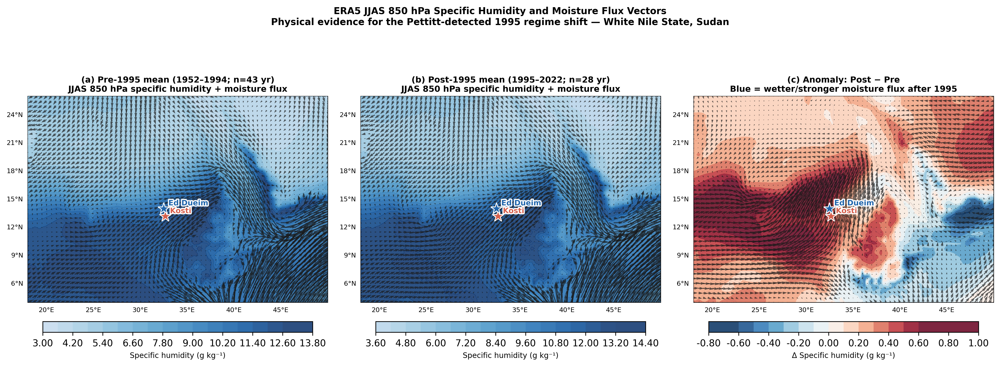

✅ Figure A1 saved: FigA1_850hPa_Regime_Shift.png


In [19]:
# CELL 9 — Figure A1: Pre/Post-1995 850 hPa composite
print('Generating Figure A1...')

pre  = years < CP_YEAR
post = years >= CP_YEAR

# Compute composites
u_pre  = u850[pre].mean(0);   v_pre  = v850[pre].mean(0)
q_pre  = q850[pre].mean(0) * 1000   # kg/kg → g/kg
u_post = u850[post].mean(0);  v_post = v850[post].mean(0)
q_post = q850[post].mean(0) * 1000
u_diff = u_post - u_pre
v_diff = v_post - v_pre
q_diff = q_post - q_pre

# Moisture flux = wind × specific humidity
mfu_pre  = u_pre  * q_pre  / 1000;  mfv_pre  = v_pre  * q_pre  / 1000
mfu_post = u_post * q_post / 1000;  mfv_post = v_post * q_post / 1000
mfu_diff = mfu_post - mfu_pre;      mfv_diff = mfv_post - mfv_pre

fig = plt.figure(figsize=(15, 5.5))

panels = [
    (1, q_pre,  mfu_pre,  mfv_pre,  'Blues',
     f'(a) Pre-1995 mean (1952–1994; n={pre.sum()} yr)\nJJAS 850 hPa specific humidity + moisture flux'),
    (2, q_post, mfu_post, mfv_post, 'Blues',
     f'(b) Post-1995 mean (1995–2022; n={post.sum()} yr)\nJJAS 850 hPa specific humidity + moisture flux'),
    (3, q_diff, mfu_diff, mfv_diff, 'RdBu_r',
     '(c) Anomaly: Post − Pre\nBlue = wetter/stronger moisture flux after 1995'),
]

for idx, Q, MFU, MFV, cmap, title in panels:
    ax, TR = make_map(fig, 1, 3, idx, title)
    vmax = np.percentile(np.abs(Q), 95)
    if idx == 3:
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    else:
        norm = plt.Normalize(vmin=0, vmax=vmax)
    cf = plot_field(ax, lons, lats, Q, cmap, norm, TR)
    cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.06,
                        shrink=0.9, aspect=25, format='%.2f')
    cbar.set_label('Specific humidity (g kg⁻¹)' if idx < 3
                   else 'Δ Specific humidity (g kg⁻¹)', fontsize=8)
    # Scale moisture flux vectors to be visible
    mf_scale = max(np.percentile(np.abs(MFU), 90), 0.01) * 25
    plot_winds(ax, lons, lats, MFU, MFV, TR, step=2, scale=mf_scale)
    mark_stations(ax, TR)
    if idx == 3:
        # Highlight Sudan domain
        kw = {'transform': TR} if CARTOPY else {}
        ax.axhspan(12, 15, color='yellow', alpha=0.08, **({} if CARTOPY else {}))

fig.suptitle(
    'ERA5 JJAS 850 hPa Specific Humidity and Moisture Flux Vectors\n'
    'Physical evidence for the Pettitt-detected 1995 regime shift — White Nile State, Sudan',
    fontsize=10, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig('FigA1_850hPa_Regime_Shift.png', bbox_inches='tight')
plt.show()
print('✅ Figure A1 saved: FigA1_850hPa_Regime_Shift.png')

---
## CELL 10 — Generate Figure A2
### AMO index + station temperature overlay

**This figure directly answers:** *"A simple linear trend could equally explain the temperature data."*

It shows the AMO transitioned from cold to warm phase precisely at 1994–1995, physically explaining the step-change as an ocean-forced regime shift rather than a gradual trend.

Generating Figure A2...


/tmp/ipykernel_2317/771581174.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


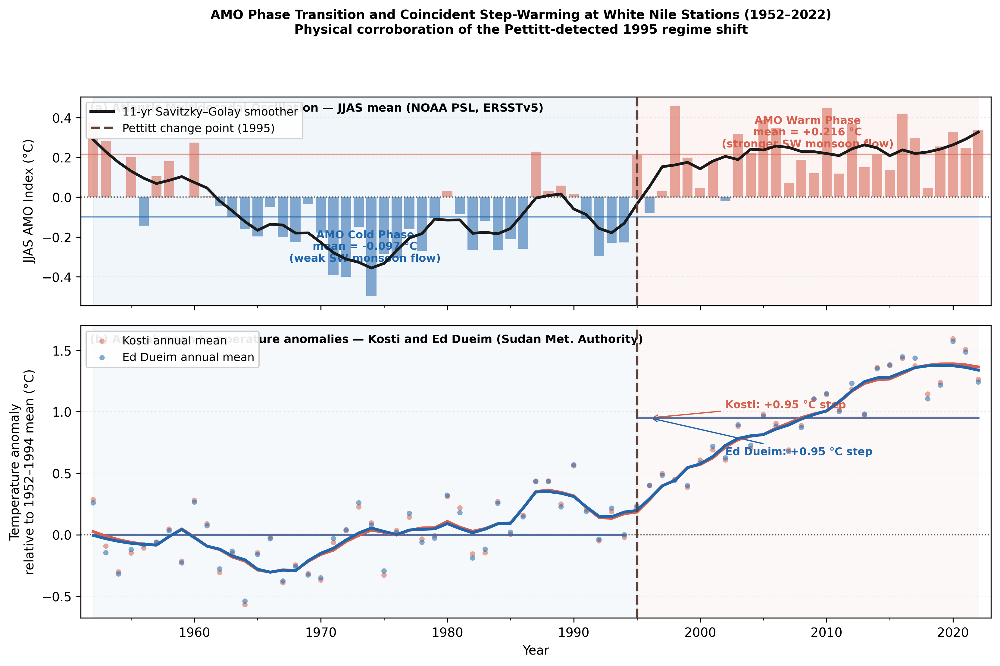

✅ Figure A2 saved: FigA2_AMO_StepWarming.png


In [20]:
# CELL 10 — Figure A2: AMO index + station temperature
print('Generating Figure A2...')

fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True,
                          gridspec_kw={'hspace': 0.08, 'height_ratios': [1, 1.4]})

# ── Panel (a): AMO ────────────────────────────────────────────────────────────
ax0 = axes[0]
amo_y = amo_df['year'].values
amo_v = amo_df['amo'].values

# 11-yr smoother
win = min(11, len(amo_v)-1 if len(amo_v) % 2 == 0 else len(amo_v))
if win < 5: win = 5
if win % 2 == 0: win -= 1
amo_sm = savgol_filter(amo_v, window_length=win, polyorder=2)

colors_amo = ['#D6604D' if v >= 0 else '#2166AC' for v in amo_v]
ax0.bar(amo_y, amo_v, color=colors_amo, alpha=0.55, width=0.8, zorder=2)
ax0.plot(amo_y, amo_sm, color='#1a1a1a', linewidth=2.2, zorder=4,
         label='11-yr Savitzky–Golay smoother')
ax0.axhline(0, color='#555', linewidth=0.9, linestyle=':', zorder=3)
ax0.axvline(CP_YEAR, color='#5D4037', linewidth=2.0, linestyle='--',
            zorder=5, label=f'Pettitt change point ({CP_YEAR})')
ax0.axvspan(amo_y[0], CP_YEAR,   color='#2166AC', alpha=0.06, zorder=1)
ax0.axvspan(CP_YEAR,  amo_y[-1], color='#D6604D', alpha=0.06, zorder=1)

pre_amo  = float(amo_df[amo_df.year < CP_YEAR]['amo'].mean())
post_amo = float(amo_df[amo_df.year >= CP_YEAR]['amo'].mean())
ax0.axhline(pre_amo,  color='#2166AC', linewidth=1.3, linestyle='-', alpha=0.6)
ax0.axhline(post_amo, color='#D6604D', linewidth=1.3, linestyle='-', alpha=0.6)

mid_pre  = (amo_y[0] + CP_YEAR) / 2
mid_post = (CP_YEAR + amo_y[-1]) / 2
ax0.text(mid_pre,  amo_v.min()*0.65,
         f'AMO Cold Phase\nmean = {pre_amo:+.3f} °C\n(weak SW monsoon flow)',
         ha='center', fontsize=8.5, color='#2166AC', fontweight='bold')
ax0.text(mid_post, amo_v.max()*0.55,
         f'AMO Warm Phase\nmean = {post_amo:+.3f} °C\n(stronger SW monsoon flow)',
         ha='center', fontsize=8.5, color='#D6604D', fontweight='bold')

ax0.set_ylabel('JJAS AMO Index (°C)', fontsize=10)
ax0.legend(fontsize=9, framealpha=0.92, edgecolor='#ccc', loc='upper left')
ax0.grid(axis='y', linestyle=':', linewidth=0.4, color='#e0e0e0')
ax0.text(0.01, 0.97, '(a) Atlantic Multidecadal Oscillation — JJAS mean (NOAA PSL, ERSSTv5)',
         transform=ax0.transAxes, fontsize=9, fontweight='bold', va='top')

# ── Panel (b): Station temperatures ──────────────────────────────────────────
ax1 = axes[1]

pre_mask  = yrs_temp < CP_YEAR
post_mask = yrs_temp >= CP_YEAR
mu_ko_pre = float(ann_ko.values[pre_mask].mean())
mu_ed_pre = float(ann_ed.values[pre_mask].mean())

anom_ko = ann_ko.values - mu_ko_pre
anom_ed = ann_ed.values - mu_ed_pre

ax1.scatter(yrs_temp, anom_ko, color='#D6604D', s=18, alpha=0.55,
            edgecolors='none', zorder=3, label='Kosti annual mean')
ax1.scatter(yrs_temp, anom_ed, color='#2166AC', s=18, alpha=0.55,
            edgecolors='none', zorder=3, label='Ed Dueim annual mean')

if len(yrs_temp) > 9:
    sm_ko = savgol_filter(anom_ko, win, 2)
    sm_ed = savgol_filter(anom_ed, win, 2)
    ax1.plot(yrs_temp, sm_ko, color='#D6604D', linewidth=2.3, zorder=5)
    ax1.plot(yrs_temp, sm_ed, color='#2166AC', linewidth=2.3, zorder=5)

ax1.axhline(0, color='#555', linewidth=0.9, linestyle=':', zorder=2)
ax1.axvline(CP_YEAR, color='#5D4037', linewidth=2.0, linestyle='--', zorder=6)
ax1.axvspan(yrs_temp[0], CP_YEAR,   color='#2166AC', alpha=0.04, zorder=1)
ax1.axvspan(CP_YEAR, yrs_temp[-1],  color='#D6604D', alpha=0.04, zorder=1)

# Pre/post mean lines
for yA, yB, anom, col in [
    (yrs_temp[0],  CP_YEAR-1, anom_ko[pre_mask].mean(),  '#D6604D'),
    (CP_YEAR,      yrs_temp[-1], anom_ko[post_mask].mean(), '#D6604D'),
    (yrs_temp[0],  CP_YEAR-1, anom_ed[pre_mask].mean(),  '#2166AC'),
    (CP_YEAR,      yrs_temp[-1], anom_ed[post_mask].mean(), '#2166AC'),
]:
    ax1.plot([yA, yB], [anom, anom], color=col, linewidth=1.8,
             linestyle='-', alpha=0.7, zorder=4)

# Annotate step sizes
ko_step = float(anom_ko[post_mask].mean() - anom_ko[pre_mask].mean())
ed_step = float(anom_ed[post_mask].mean() - anom_ed[pre_mask].mean())
ax1.annotate(f'Kosti: +{ko_step:.2f} °C step',
             xy=(CP_YEAR+1, anom_ko[post_mask].mean()),
             xytext=(CP_YEAR+7, anom_ko[post_mask].mean()+0.08),
             fontsize=8.5, color='#D6604D', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#D6604D', lw=1.0))
ax1.annotate(f'Ed Dueim: +{ed_step:.2f} °C step',
             xy=(CP_YEAR+1, anom_ed[post_mask].mean()),
             xytext=(CP_YEAR+7, anom_ed[post_mask].mean()-0.30),
             fontsize=8.5, color='#2166AC', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#2166AC', lw=1.0))

ax1.set_ylabel('Temperature anomaly\nrelative to 1952–1994 mean (°C)', fontsize=10)
ax1.set_xlabel('Year', fontsize=10)
ax1.legend(fontsize=9, framealpha=0.92, edgecolor='#ccc', loc='upper left')
ax1.grid(axis='y', linestyle=':', linewidth=0.4, color='#e0e0e0')
ax1.text(0.01, 0.97,
         '(b) Annual mean temperature anomalies — Kosti and Ed Dueim (Sudan Met. Authority)',
         transform=ax1.transAxes, fontsize=9, fontweight='bold', va='top')
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(5))
ax1.set_xlim(yrs_temp[0]-1, yrs_temp[-1]+1)

fig.suptitle(
    'AMO Phase Transition and Coincident Step-Warming at White Nile Stations (1952–2022)\n'
    'Physical corroboration of the Pettitt-detected 1995 regime shift',
    fontsize=10, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig('FigA2_AMO_StepWarming.png', bbox_inches='tight')
plt.show()
print('✅ Figure A2 saved: FigA2_AMO_StepWarming.png')

---
## CELL 11 — Generate Figure A3
### TEJ (200 hPa) + AEJ (600 hPa): ENSO composites

**This figure directly answers:** *"ENSO explored only correlationally — causal circulation connections needed."*

It shows that ENSO physically modulates the Tropical Easterly Jet (TEJ) and African Easterly Jet (AEJ) over Sudan — the established atmospheric pathway from Pacific SST anomalies to Sahelian rainfall.

Generating Figure A3...


/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been

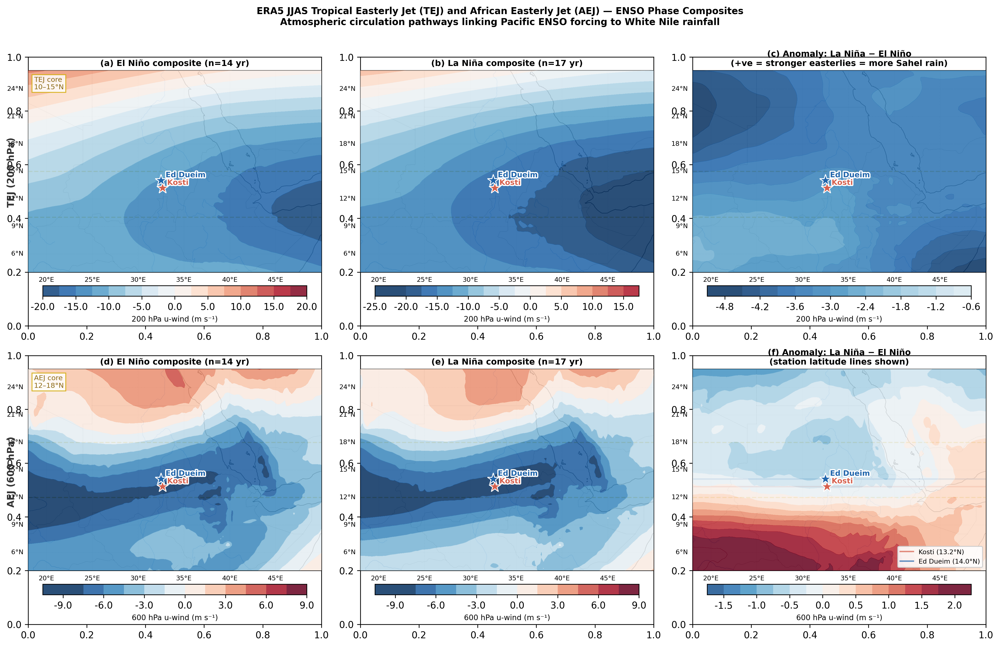

✅ Figure A3 saved: FigA3_TEJ_AEJ_ENSO.png


In [22]:
# CELL 11 — Figure A3: TEJ and AEJ ENSO composites
print('Generating Figure A3...')

# Composites
u200_en = u200[en_mask].mean(0); u200_ln = u200[ln_mask].mean(0)
u200_di = u200_ln - u200_en
u600_en = u600[en_mask].mean(0); u600_ln = u600[ln_mask].mean(0)
u600_di = u600_ln - u600_en

fig, axes_all = plt.subplots(2, 3, figsize=(15, 9.5))

row_configs = [
    # (data_en, data_ln, data_di, label, colorbar_label, lat_lines, lat_label)
    (u200_en, u200_ln, u200_di,
     'TEJ — 200 hPa Zonal Wind (m s⁻¹)',
     '200 hPa u-wind (m s⁻¹)',
     [10, 15], 'TEJ core\n10–15°N'),
    (u600_en, u600_ln, u600_di,
     'AEJ — 600 hPa Zonal Wind (m s⁻¹)',
     '600 hPa u-wind (m s⁻¹)',
     [12, 18], 'AEJ core\n12–18°N'),
]

titles_top = [
    f'(a) El Niño composite (n={en_mask.sum()} yr)',
    f'(b) La Niña composite (n={ln_mask.sum()} yr)',
    '(c) Anomaly: La Niña − El Niño\n(+ve = stronger easterlies = more Sahel rain)',
]
titles_bot = [
    f'(d) El Niño composite (n={en_mask.sum()} yr)',
    f'(e) La Niña composite (n={ln_mask.sum()} yr)',
    '(f) Anomaly: La Niña − El Niño\n(station latitude lines shown)',
]

for row_i, (den, dln, ddi, row_label, cbar_lbl, lat_lines, lat_lbl) in enumerate(row_configs):
    titles = titles_top if row_i == 0 else titles_bot
    for col_i, (data, panel_title) in enumerate(zip([den, dln, ddi], titles)):
        ax, TR = make_map(fig, 2, 3, row_i*3+col_i+1, panel_title)
        vmax = np.percentile(np.abs(np.concatenate([den, dln])), 96)
        dmax = np.percentile(np.abs(ddi), 95)
        norm = (TwoSlopeNorm(vmin=-dmax, vcenter=0, vmax=dmax)
                if col_i == 2
                else TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax))
        cf = plot_field(ax, lons, lats, data, 'RdBu_r', norm, TR)
        cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05,
                            shrink=0.9, aspect=25, format='%.1f')
        cbar.set_label(cbar_lbl, fontsize=8)
        # Jet core latitude bands
        for lat_l in lat_lines:
            # Removed **kw from ax.axhline as it doesn't accept 'transform'
            ax.axhline(lat_l, color='#D4AC0D', linewidth=1.2,
                       linestyle='--', alpha=0.8)
        if col_i == 0:
            kw = {'transform': TR} if CARTOPY else {}
            ax.text(0.02, 0.97, lat_lbl, transform=ax.transAxes,
                    fontsize=7.5, va='top', color='#8B6914',
                    bbox=dict(fc='white', ec='#D4AC0D', pad=2, alpha=0.85))
        # Station latitude lines on anomaly panel
        if col_i == 2 and row_i == 1:
            for lat_s, col_s, nm in [
                (KOSTI_LAT, '#D6604D', 'Kosti (13.2°N)'),
                (EDDUEIM_LAT, '#2166AC', 'Ed Dueim (14.0°N)')
            ]:
                # Removed **kw from ax.axhline as it doesn't accept 'transform'
                ax.axhline(lat_s, color=col_s, linewidth=1.5,
                           linestyle='-', alpha=0.7, label=nm)
            ax.legend(fontsize=7, framealpha=0.9, loc='lower right')
        mark_stations(ax, TR)

# Row labels
fig.text(0.01, 0.75, 'TEJ (200 hPa)', va='center', rotation='vertical',
         fontsize=10, fontweight='bold', color='#333')
fig.text(0.01, 0.28, 'AEJ (600 hPa)', va='center', rotation='vertical',
         fontsize=10, fontweight='bold', color='#333')

fig.suptitle(
    'ERA5 JJAS Tropical Easterly Jet (TEJ) and African Easterly Jet (AEJ) — ENSO Phase Composites\n'
    'Atmospheric circulation pathways linking Pacific ENSO forcing to White Nile rainfall',
    fontsize=10, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig('FigA3_TEJ_AEJ_ENSO.png', bbox_inches='tight')
plt.show()
print('✅ Figure A3 saved: FigA3_TEJ_AEJ_ENSO.png')

---
## CELL 12 — Generate Figure A4
### VIMFD moisture convergence + 850 hPa wind: ENSO composites

**This completes the causal chain:** ENSO → Walker Circulation → TEJ → low-level moisture flux → convergence → rainfall.

It shows directly that La Niña years produce stronger moisture convergence (negative VIMFD) over the Sudan corridor, providing the physical mechanism for the ENSO–rainfall signal.

Generating Figure A4...


/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


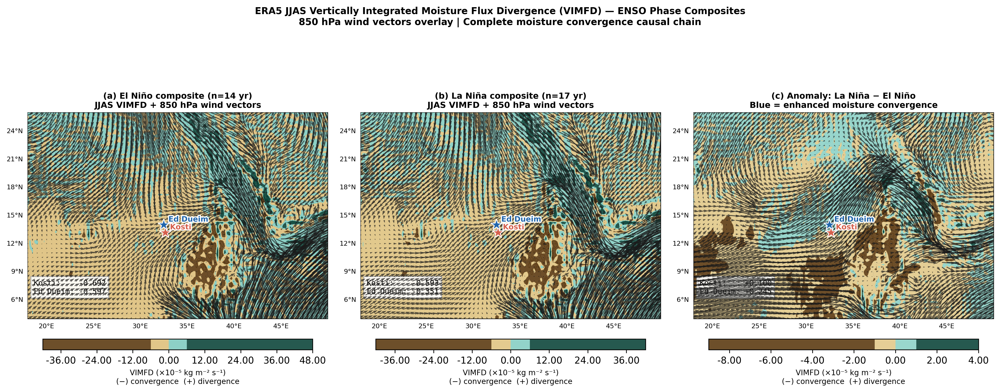

✅ Figure A4 saved: FigA4_VIMFD_ENSO.png


In [23]:
# CELL 12 — Figure A4: VIMFD + 850 hPa wind ENSO composites
print('Generating Figure A4...')

# VIMFD composites (convert to ×10⁻⁵ kg m⁻² s⁻¹)
v_en  = vimfd[en_mask].mean(0) * 1e5
v_ln  = vimfd[ln_mask].mean(0) * 1e5
v_di  = v_ln - v_en

# 850 hPa winds
u_en_850 = u850[en_mask].mean(0); v_en_850 = v850[en_mask].mean(0)
u_ln_850 = u850[ln_mask].mean(0); v_ln_850 = v850[ln_mask].mean(0)
u_di_850 = u_ln_850 - u_en_850;   v_di_850 = v_ln_850 - v_en_850

fig = plt.figure(figsize=(15, 5.8))

panels = [
    (1, v_en, u_en_850, v_en_850,
     f'(a) El Niño composite (n={en_mask.sum()} yr)\nJJAS VIMFD + 850 hPa wind vectors'),
    (2, v_ln, u_ln_850, v_ln_850,
     f'(b) La Niña composite (n={ln_mask.sum()} yr)\nJJAS VIMFD + 850 hPa wind vectors'),
    (3, v_di, u_di_850, v_di_850,
     '(c) Anomaly: La Niña − El Niño\nBlue = enhanced moisture convergence'),
]

for idx, VIMD, U8, V8, title in panels:
    ax, TR = make_map(fig, 1, 3, idx, title)
    vmax = np.percentile(np.abs(VIMD), 95)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cf = plot_field(ax, lons, lats, VIMD, 'BrBG', norm, TR, levels=14)
    cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.06,
                        shrink=0.9, aspect=25, format='%.2f')
    cbar.set_label('VIMFD (×10⁻⁵ kg m⁻² s⁻¹)\n(−) convergence  (+) divergence',
                   fontsize=8)
    plot_winds(ax, lons, lats, U8, V8, TR, step=2,
               scale=max(np.percentile(np.abs(U8),90),0.5)*15)
    mark_stations(ax, TR)

    # Station VIMFD values
    ko_i = np.argmin(np.abs(lats - KOSTI_LAT))
    ko_j = np.argmin(np.abs(lons - KOSTI_LON))
    ed_i = np.argmin(np.abs(lats - EDDUEIM_LAT))
    ed_j = np.argmin(np.abs(lons - EDDUEIM_LON))
    ax.text(0.02, 0.12,
            f'Kosti:    {VIMD[ko_i,ko_j]:+.3f}\nEd Dueim: {VIMD[ed_i,ed_j]:+.3f}',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(fc='white', ec='#aaa', pad=3, alpha=0.9),
            fontfamily='monospace')

fig.suptitle(
    'ERA5 JJAS Vertically Integrated Moisture Flux Divergence (VIMFD) — ENSO Phase Composites\n'
    '850 hPa wind vectors overlay | Complete moisture convergence causal chain',
    fontsize=10, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig('FigA4_VIMFD_ENSO.png', bbox_inches='tight')
plt.show()
print('✅ Figure A4 saved: FigA4_VIMFD_ENSO.png')

---
## CELL 13 — Download all figures to your computer

Run this to download all four figures at once.

In [24]:
# CELL 13 — Download all figures
from google.colab import files
import os

figure_files = [
    'FigA1_850hPa_Regime_Shift.png',
    'FigA2_AMO_StepWarming.png',
    'FigA3_TEJ_AEJ_ENSO.png',
    'FigA4_VIMFD_ENSO.png',
]

for fname in figure_files:
    if os.path.exists(fname):
        files.download(fname)
        print(f'✅ Downloaded: {fname}')
    else:
        print(f'❌ Not found: {fname} — did the figure cell run without errors?')

print('\n🎉 All done! You now have four publication-quality figures.')
print('   Add them to your manuscript revision.')
print('\n   Citation for ERA5:')
print('   Hersbach H et al (2020) The ERA5 global reanalysis.')
print('   Q J R Meteorol Soc 146(730):1999–2049.')
print('   https://doi.org/10.1002/qj.3803')
print('\n   Citation for AMO index:')
print('   Enfield DB, Mestas-Nuñez AM, Trimble PJ (2001)')
print('   Geophys Res Lett 28(10):2077–2080.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: FigA1_850hPa_Regime_Shift.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: FigA3_TEJ_AEJ_ENSO.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: FigA4_VIMFD_ENSO.png

🎉 All done! You now have four publication-quality figures.
   Add them to your manuscript revision.

   Citation for ERA5:
   Hersbach H et al (2020) The ERA5 global reanalysis.
   Q J R Meteorol Soc 146(730):1999–2049.
   https://doi.org/10.1002/qj.3803

   Citation for AMO index:
   Enfield DB, Mestas-Nuñez AM, Trimble PJ (2001)
   Geophys Res Lett 28(10):2077–2080.
